# Análise de exposição por histograma
*Os textos deste codigo foram feitos com auxilio de inteligencia artificial*

**Aluno:** _Antonio Heitor_

Três fotos: uma escura demais (meu macaco de pelucia), uma clara/saturada demais (Print branco) e uma bem exposta (Minha cadela florinda). Para cada uma: tons de cinza + histograma, diagnóstico, uma operação de ajuste com justificativa/parâmetro e a figura antes × depois. No fim, o parágrafo respondendo em qual delas a operação fez menos diferença.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()


Saving florinda.jpg to florinda.jpg
Saving print.jpg to print.jpg
Saving macaco.jpg to macaco.jpg


In [2]:
CAMINHO_ESCURA = "macaco.jpg"     # escura demais
CAMINHO_CLARA  = "print.jpg"      # clara / saturada demais
CAMINHO_BOA    = "florinda.jpg"   # bem exposta

In [3]:
def ler_cinza(caminho, maxlado=640):
    # 1) le a imagem (BGR)  2) reduz um pouco (p/ o histograma de laco rodar rapido)
    # 3) converte para tons de cinza
    img_bgr = cv2.imread(caminho)
    if img_bgr is None:
        raise FileNotFoundError("Nao encontrei: " + caminho)
    h, w = img_bgr.shape[:2]
    escala = maxlado / max(h, w)
    if escala < 1:
        img_bgr = cv2.resize(img_bgr, (int(w*escala), int(h*escala)),
                             interpolation=cv2.INTER_AREA)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    return img_gray

escura = ler_cinza(CAMINHO_ESCURA)
clara  = ler_cinza(CAMINHO_CLARA)
boa    = ler_cinza(CAMINHO_BOA)
print("shapes:", escura.shape, clara.shape, boa.shape)

shapes: (640, 480) (640, 457) (640, 480)


## Função de histograma
Percorre a imagem pixel a pixel e conta quantos existem de cada intensidade (0–255).

In [4]:
def calc_hist(img):
    img_vetor = img.ravel()          # desmembra a matriz em um vetor
    hist_vetor = np.zeros(256)
    for px in img_vetor:             # p/ cada pixel, incrementa a posicao correspondente
        hist_vetor[px] += 1
    return hist_vetor

## Operações (uma será escolhida por imagem)

In [5]:
def expandir_contraste(img, L, H):
    # estica linearmente a faixa [L, H] para [0, 255]
    x = img.astype(np.float32)
    y = (x - L) * 255.0 / (H - L)
    return np.clip(y, 0, 255).astype(np.uint8)

def equalizar(img):
    return cv2.equalizeHist(img)

def corrigir_gamma(img, gamma):
    # s = 255 * (r/255)^gamma  (via tabela de lookup)
    tabela = np.array([((i/255.0)**gamma)*255 for i in range(256)])
    tabela = np.clip(tabela, 0, 255).astype(np.uint8)
    return cv2.LUT(img, tabela)

In [6]:
def mostrar_antes_depois(antes, depois, titulo):
    fig, ax = plt.subplots(2, 2, figsize=(10, 7))
    ax[0,0].imshow(antes,  cmap="gray", vmin=0, vmax=255); ax[0,0].set_title("Antes");  ax[0,0].axis("off")
    ax[0,1].imshow(depois, cmap="gray", vmin=0, vmax=255); ax[0,1].set_title("Depois"); ax[0,1].axis("off")
    ax[1,0].bar(range(256), calc_hist(antes));  ax[1,0].set_title("Histograma - antes");  ax[1,0].set_xlim(0,255)
    ax[1,1].bar(range(256), calc_hist(depois)); ax[1,1].set_title("Histograma - depois"); ax[1,1].set_xlim(0,255)
    fig.suptitle(titulo, fontweight="bold")
    fig.tight_layout(); plt.show()

## 1. Imagem escura demais (macaco)

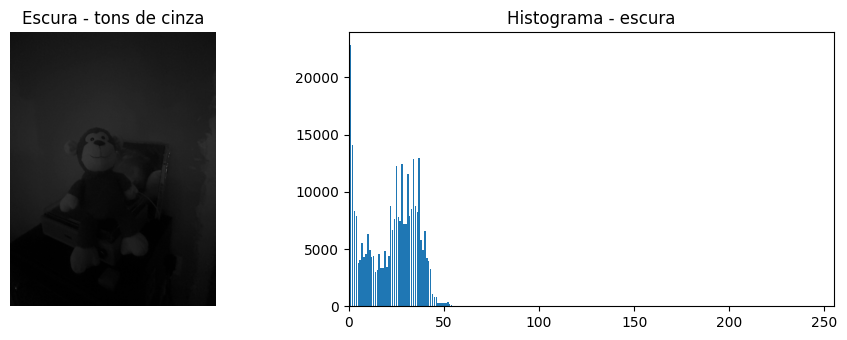

media: 22.2  min: 0  max: 149


In [7]:
plt.figure(figsize=(10, 3.5))
plt.subplot(1,2,1); plt.imshow(escura, cmap="gray", vmin=0, vmax=255)
plt.title("Escura - tons de cinza"); plt.axis("off")
plt.subplot(1,2,2); plt.bar(range(256), calc_hist(escura)); plt.xlim(0,255)
plt.title("Histograma - escura")
plt.tight_layout(); plt.show()
print("media:", round(float(escura.mean()),1), " min:", int(escura.min()), " max:", int(escura.max()))

Diagnóstico: as intensidades estão quase todas coladas no lado esquerdo (perto de 0) média em torno de 22 e praticamente 100% dos pixels abaixo de 64. É uma imagem subexposta: as sombras dominam e quase toda a metade clara da escala fica vazia, então há muito pouco detalhe visível.

Operação escolhida: correção de gamma (γ = 0.4). Como o problema é falta de luz, γ < 1 clareia de forma não linear, levantando bastante as sombras (a média sobe de ~22 para ~89) sem precisar recortar faixa. Parâmetro: γ = 0.4

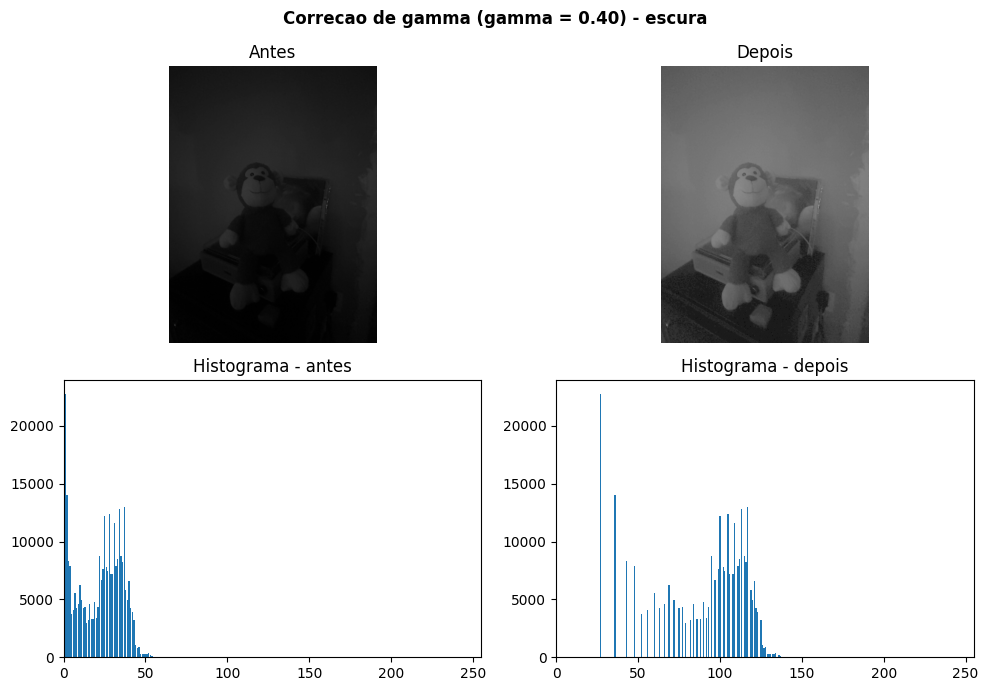

In [8]:
GAMMA = 0.4
escura_corr = corrigir_gamma(escura, GAMMA)
mostrar_antes_depois(escura, escura_corr, "Correcao de gamma (gamma = %.2f) - escura" % GAMMA)

## 2. Imagem clara / saturada demais (print)

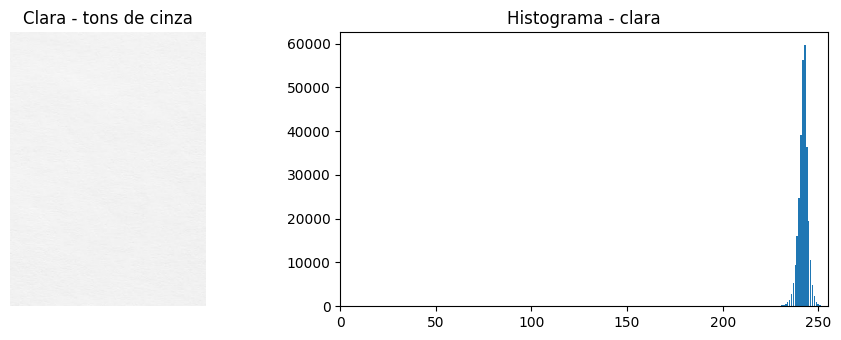

media: 242.1  desvio: 2.5  min: 219  max: 255


In [9]:
plt.figure(figsize=(10, 3.5))
plt.subplot(1,2,1); plt.imshow(clara, cmap="gray", vmin=0, vmax=255)
plt.title("Clara - tons de cinza"); plt.axis("off")
plt.subplot(1,2,2); plt.bar(range(256), calc_hist(clara)); plt.xlim(0,255)
plt.title("Histograma - clara")
plt.tight_layout(); plt.show()
print("media:", round(float(clara.mean()),1), " desvio:", round(float(clara.std()),1),
      " min:", int(clara.min()), " max:", int(clara.max()))

Diagnóstico: tudo espremido no extremo direito (perto de 255) média 242 e desvio de só 3, com 100% dos pixels acima de 192. É uma imagem superexposta e de contraste baixíssimo: a variação real (a textura do papel) existe, mas está comprimida numa faixa estreita (214–255) e por isso quase invisível.

Operação escolhida: equalização de histograma. Como os valores estão amontoados numa faixa curta no alto, a equalização redistribui essas intensidades por toda a escala [0, 255], devolvendo contraste e revelando a textura. É automática, então não há parâmetro L/H ou γ a informar.

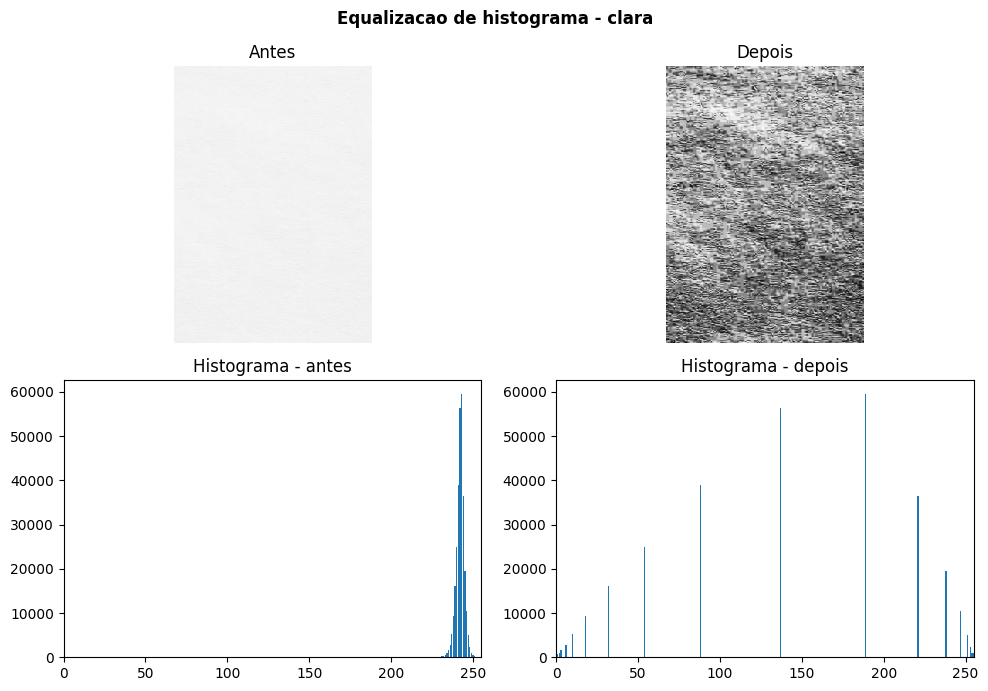

In [10]:
clara_corr = equalizar(clara)
mostrar_antes_depois(clara, clara_corr, "Equalizacao de histograma - clara")

## 3. Imagem bem exposta (florinda linda)

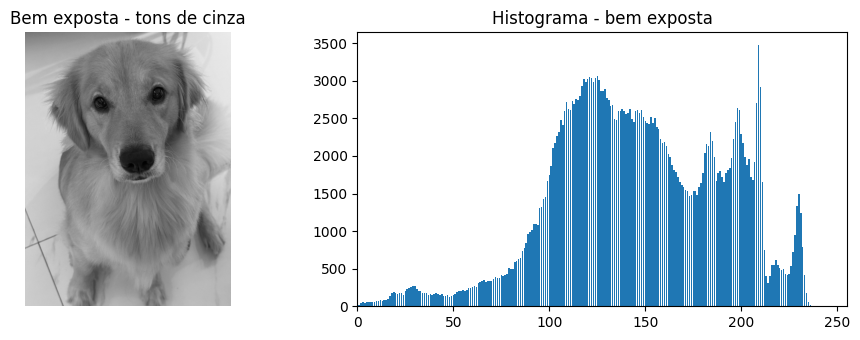

media: 146.3  min: 1  max: 237


In [11]:
plt.figure(figsize=(10, 3.5))
plt.subplot(1,2,1); plt.imshow(boa, cmap="gray", vmin=0, vmax=255)
plt.title("Bem exposta - tons de cinza"); plt.axis("off")
plt.subplot(1,2,2); plt.bar(range(256), calc_hist(boa)); plt.xlim(0,255)
plt.title("Histograma - bem exposta")
plt.tight_layout(); plt.show()
print("media:", round(float(boa.mean()),1), " min:", int(boa.min()), " max:", int(boa.max()))

Diagnóstico: as intensidades se espalham por quase toda a faixa (de 0 a 240), com a maior parte nos meios-tons (78%). É uma imagem bem exposta: tem sombra (olhos, focinho), meio-tom (pelo) e alta luz (piso/fundo) bem representados.

Operação escolhida: expansão de contraste (L = mínimo, H = máximo da imagem). Como ela já usa quase toda a escala, apenas "encosto" os extremos em 0 e 255 um ajuste suave. Parâmetros L e H tirados do próprio histograma (impressos abaixo).

L = 1   H = 237


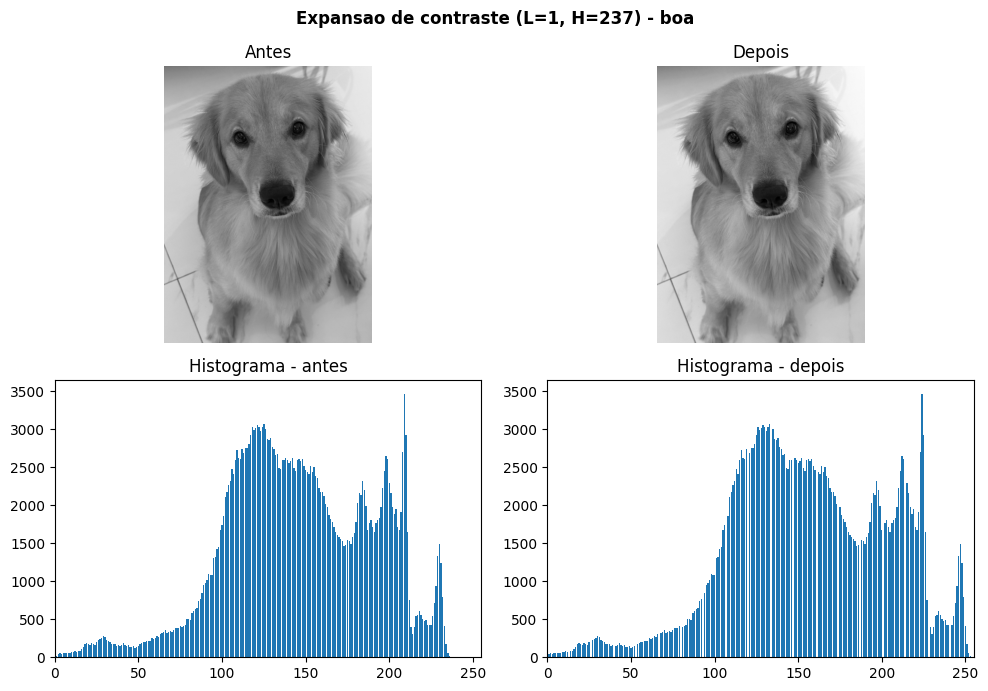

In [12]:
L = int(boa.min()); H = int(boa.max())
print("L =", L, "  H =", H)
boa_corr = expandir_contraste(boa, L, H)
mostrar_antes_depois(boa, boa_corr, "Expansao de contraste (L=%d, H=%d) - boa" % (L, H))

## 4. Resposta final

**Em qual das três imagens a operação fez menos diferença? Por quê?**

Na imagem bem exposta (a florinda). O histograma dela já ocupava quase toda a faixa [0, 255] e estava concentrado nos meios-tons, então a expansão de contraste só teve que esticar os poucos níveis não usados nas pontas, a mudança foi mínima (a diferença média por pixel ficou em torno de 10 níveis, e a média foi de 146 para 157). Nas outras duas, as intensidades estavam amontoadas em um extremo (perto de 0 na escura, perto de 255 na clara), deixando a maior parte da escala vazia; por isso a correção de gamma e a equalização tiveram muito "espaço" para redistribuir os tons e mudaram bem mais (diferença média por pixel de cerca de 66 na escura e 99 na clara). Ou seja: quanto mais o histograma original já preenche a faixa toda, menos qualquer operação de contraste/exposição tem a corrigir.